# Slippage Analysis

**Key question:** Does the entry/exit asymmetry (limit entries vs market exits) affect fill quality?

Compares slippage in basis points across order tiers: **exit / strong / moderate / weak**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

DATA_DIR = './output'
print('Config OK')

Config OK


In [2]:
slip = pd.read_csv(f'{DATA_DIR}/slippage.csv',     parse_dates=['date'])
oe   = pd.read_csv(f'{DATA_DIR}/order_events.csv', parse_dates=['date'])
print(f'Slippage records: {len(slip):,} | Order events: {len(oe):,}')
slip.head(3)

Slippage records: 921 | Order events: 3,631


,date,order_id,symbol,direction,quantity,expected_price,fill_price,slippage_bps
0,2020-01-02,1,AAPL,Buy,1.0,269.994146,269.9941,-0.0017
1,2020-01-02,3,AXP,Sell,-2.0,264.796490,266.1205,50.0010
2,2020-01-02,5,CAT,Sell,-3.0,115.209093,116.9372,149.9975


In [3]:
# Compute adverse slippage in bps
if 'expected_price' in slip.columns and 'fill_price' in slip.columns:
    slip['raw_slippage_bps'] = (slip['fill_price'] - slip['expected_price']) / slip['expected_price'] * 10_000
    slip['is_buy'] = slip['direction'].str.lower().isin(['buy'])
    # Adverse = paid more (buy) or received less (sell)
    slip['adverse_slippage_bps'] = np.where(slip['is_buy'],
                                             slip['raw_slippage_bps'],
                                            -slip['raw_slippage_bps'])
    print(f'Mean adverse slippage : {slip["adverse_slippage_bps"].mean():.3f} bps')
    print(f'Std  adverse slippage : {slip["adverse_slippage_bps"].std():.3f} bps')
    slip[['adverse_slippage_bps','raw_slippage_bps']].describe().round(3)

Mean adverse slippage : -37.188 bps
Std  adverse slippage : 51.275 bps


In [4]:
# Extract order tier from tag in order_events and merge
def extract_tier(tag):
    if pd.isna(tag): return 'unknown'
    t = str(tag).lower()
    for k in ['exit','strong','moderate','weak']:
        if k in t: return k
    return 'unknown'

filled_oe = oe[oe['status']=='Filled'][['order_id','tag','order_type']].copy()
filled_oe['tier'] = filled_oe['tag'].apply(extract_tier)

if 'order_id' in slip.columns:
    slip = slip.merge(filled_oe[['order_id','tier','order_type']], on='order_id', how='left')
else:
    slip['tier'] = 'unknown'

print('Tier distribution:')
print(slip['tier'].value_counts())

Tier distribution:
tier
moderate    289
strong      274
exit        226
weak        132
Name: count, dtype: int64


In [5]:
# Slippage stats by tier
tier_order = ['exit','strong','moderate','weak','unknown']
colors     = {'exit':'crimson','strong':'steelblue','moderate':'darkorange','weak':'green','unknown':'grey'}

by_tier = (slip.groupby('tier')['adverse_slippage_bps']
              .agg(['mean','std','median','count'])
              .reindex(tier_order).dropna())
print('\nSlippage by tier (bps):')
print(by_tier.round(3))


Slippage by tier (bps):
           mean    std  median  count
tier                                 
exit        0.0  0.000     0.0  226.0
strong      0.0  0.002     0.0  274.0
moderate  -50.0  0.001   -50.0  289.0
weak     -150.0  0.002  -150.0  132.0


C:\Users\ACER\AppData\Local\Temp\ipykernel_19628\3217171161.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=plot_tiers, patch_artist=True, showfliers=False)


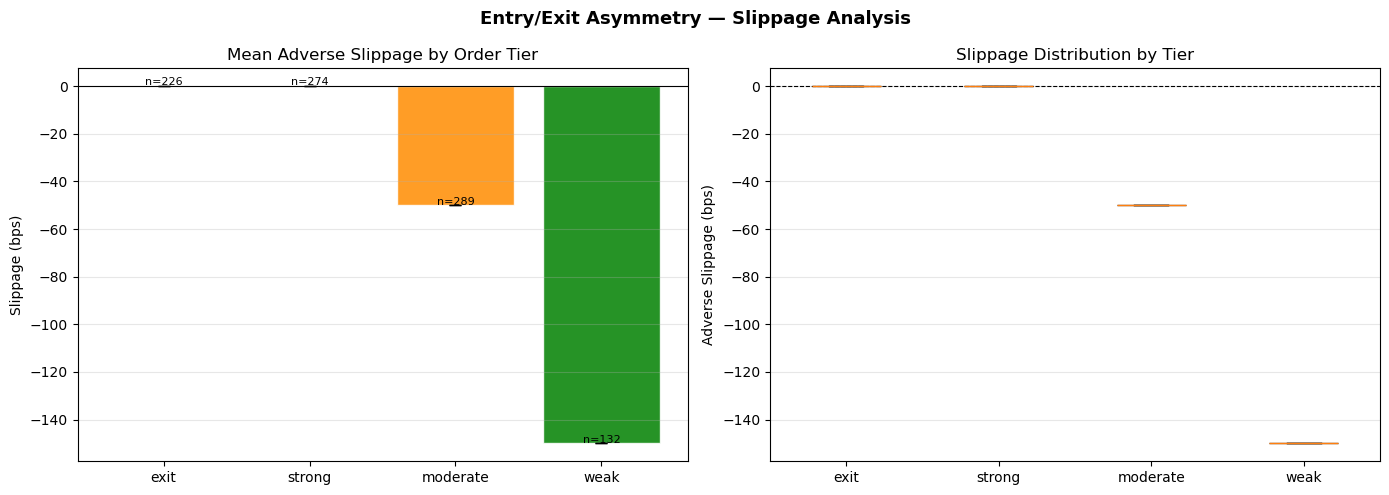

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar: mean slippage per tier
ax = axes[0]
ax.bar(by_tier.index, by_tier['mean'],
       color=[colors.get(t,'grey') for t in by_tier.index],
       yerr=by_tier['std'], capsize=4, alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Mean Adverse Slippage by Order Tier', fontsize=12)
ax.set_ylabel('Slippage (bps)'); ax.grid(axis='y', alpha=0.3)
for i, (t, row) in enumerate(by_tier.iterrows()):
    ax.text(i, row['mean'] + row['std']*0.1 + 0.3, f"n={int(row['count'])}",
            ha='center', fontsize=8)

# Box: distribution per tier
ax = axes[1]
plot_tiers = [t for t in tier_order if t in slip['tier'].values]
plot_data  = [slip[slip['tier']==t]['adverse_slippage_bps'].dropna().values for t in plot_tiers]
bp = ax.boxplot(plot_data, labels=plot_tiers, patch_artist=True, showfliers=False)
for patch, t in zip(bp['boxes'], plot_tiers):
    patch.set_facecolor(colors.get(t,'grey')); patch.set_alpha(0.75)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_title('Slippage Distribution by Tier', fontsize=12)
ax.set_ylabel('Adverse Slippage (bps)'); ax.grid(axis='y', alpha=0.3)

plt.suptitle('Entry/Exit Asymmetry — Slippage Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/slippage_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Limit offset effectiveness: did the 0.5% / 1.5% offsets save money vs market price?
if 'market_price_at_submit' in slip.columns:
    sub = slip[slip['market_price_at_submit'].notna() & (slip['tier'] != 'exit')].copy()
    sub['saving_bps'] = np.where(
        sub['is_buy'],
        (sub['market_price_at_submit'] - sub['fill_price']) / sub['market_price_at_submit'] * 10_000,
        (sub['fill_price'] - sub['market_price_at_submit']) / sub['market_price_at_submit'] * 10_000
    )
    print('Limit order saving vs market price (bps) by tier:')
    print(sub.groupby('tier')['saving_bps'].agg(['mean','std','count']).round(3))

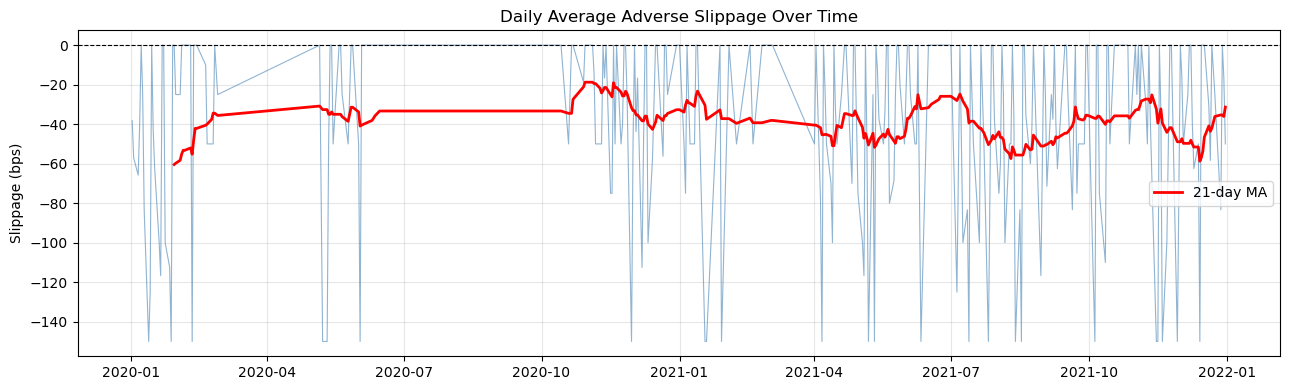

In [8]:
# Slippage over time
daily = slip.groupby('date')['adverse_slippage_bps'].mean()
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(daily.index, daily.values, color='steelblue', lw=0.8, alpha=0.6)
ax.plot(daily.index, daily.rolling(21).mean(), color='red', lw=2, label='21-day MA')
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_title('Daily Average Adverse Slippage Over Time', fontsize=12)
ax.set_ylabel('Slippage (bps)'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [9]:
print('=== Slippage Summary ===')
print(f'Total fills          : {len(slip):,}')
print(f'Mean adverse slip    : {slip["adverse_slippage_bps"].mean():.3f} bps')
print(f'Median adverse slip  : {slip["adverse_slippage_bps"].median():.3f} bps')
print(f'% fills > 5 bps      : {(slip["adverse_slippage_bps"] > 5).mean()*100:.1f}%')
print(f'% favourable (<0 bps): {(slip["adverse_slippage_bps"] < 0).mean()*100:.1f}%')

=== Slippage Summary ===
Total fills          : 921
Mean adverse slip    : -37.188 bps
Median adverse slip  : -0.002 bps
% fills > 5 bps      : 0.0%
% favourable (<0 bps): 59.9%
